# Cosine Similarity Between Vectors

This notebook demonstrates how to compute cosine similarity between vectors using PyTorch and explores its relationship with the Law of Cosines.

## What is Cosine Similarity?

Cosine similarity is a measure of similarity between two vectors based on the cosine of the angle between them. It measures how similar two vectors are in terms of their direction, regardless of their magnitude. The cosine similarity ranges from -1 to 1, where 1 means identical direction, 0 means orthogonal (perpendicular), and -1 means opposite direction.

### Mathematical Definition

For two vectors $\mathbf{u}, \mathbf{v} \in \mathbb{R}^d$ in $d$-dimensional space:

$$\text{cos}(\theta) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|_2 \|\mathbf{v}\|_2} = \frac{\sum_{i=1}^{d} u_i v_i}{\sqrt{\sum_{i=1}^{d} u_i^2} \sqrt{\sum_{i=1}^{d} v_i^2}}$$

where:
- $\mathbf{u} \cdot \mathbf{v}$ is the dot product of the vectors
- $\|\mathbf{u}\|_2$ is the L2 norm (magnitude) of vector $\mathbf{u}$
- $\|\mathbf{v}\|_2$ is the L2 norm (magnitude) of vector $\mathbf{v}$
- $\theta$ is the angle between the vectors

**Key Properties**:

- Cosine similarity is always between **-1 and 1**: $-1 \leq \cos(\theta) \leq 1$

- When $\cos(\theta) = 1$: vectors point in the **same direction** (parallel)

- When $\cos(\theta) = 0$: vectors are **orthogonal** (perpendicular)

- When $\cos(\theta) = -1$: vectors point in **opposite directions**

- Cosine similarity is **scale-invariant**: scaling a vector doesn't change the similarity

- Cosine similarity is **symmetric**: $\cos(\mathbf{u}, \mathbf{v}) = \cos(\mathbf{v}, \mathbf{u})$

- For **non-negative vectors**, cosine similarity equals **Cosine Distance** = $1 - \cos(\theta)$

## Law of Cosines

The **Law of Cosines** is a fundamental theorem in geometry that relates the sides of a triangle to the cosine of one of its angles. It provides the mathematical foundation for understanding the relationship between vector magnitudes, distances, and angles.

### Mathematical Definition

For a triangle with sides of length $a$, $b$, and $c$, where $c$ is opposite to angle $\theta$:

$$c^2 = a^2 + b^2 - 2ab \cos(\theta)$$

Rearranging to solve for the cosine:

$$\cos(\theta) = \frac{a^2 + b^2 - c^2}{2ab}$$

### Relationship to Vector Geometry

In the context of vectors $\mathbf{u}$ and $\mathbf{v}$:
- $a = \|\mathbf{u}\|$ (magnitude of vector $\mathbf{u}$)
- $b = \|\mathbf{v}\|$ (magnitude of vector $\mathbf{v}$)
- $c = \|\mathbf{u} - \mathbf{v}\|$ (magnitude of the difference vector, i.e., Euclidean distance)
- $\theta$ is the angle between vectors $\mathbf{u}$ and $\mathbf{v}$

Therefore, the Law of Cosines becomes:

$$\|\mathbf{u} - \mathbf{v}\|^2 = \|\mathbf{u}\|^2 + \|\mathbf{v}\|^2 - 2\|\mathbf{u}\| \|\mathbf{v}\| \cos(\theta)$$

This can be rearranged to:

$$\cos(\theta) = \frac{\|\mathbf{u}\|^2 + \|\mathbf{v}\|^2 - \|\mathbf{u} - \mathbf{v}\|^2}{2\|\mathbf{u}\| \|\mathbf{v}\|} = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \|\mathbf{v}\|}$$

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Create two vectors with a larger angle for clear visualization
u = torch.tensor([3.0, 0.0])
v = torch.tensor([1.0, 3.0])

print(f"Vector u = {u}")
print(f"Vector v = {v}")

Vector u = tensor([3., 0.])
Vector v = tensor([1., 3.])


In [2]:
# Calculate dot product
dot_product = torch.dot(u, v)
print(f"Dot product: u · v = {dot_product}")
print(f"Calculation: (3 × 1) + (0 × 3) = {dot_product}")

Dot product: u · v = 3.0
Calculation: (3 × 1) + (0 × 3) = 3.0


In [3]:
# Calculate magnitudes
magnitude_u = torch.norm(u)
magnitude_v = torch.norm(v)
print(f"Magnitude of u: ||u|| = {magnitude_u:.4f}")
print(f"Magnitude of v: ||v|| = {magnitude_v:.4f}")

Magnitude of u: ||u|| = 3.0000
Magnitude of v: ||v|| = 3.1623


In [4]:
# Calculate cosine similarity
cosine_similarity = dot_product / (magnitude_u * magnitude_v)
print(f"Cosine Similarity: cos(θ) = {cosine_similarity:.4f}")
print(f"Calculation: {dot_product} / ({magnitude_u:.4f} × {magnitude_v:.4f}) = {cosine_similarity:.4f}")

# Calculate angle in radians and degrees
angle_rad = torch.acos(cosine_similarity)
angle_deg = torch.rad2deg(angle_rad)
print(f"\nAngle between vectors: θ = {angle_deg:.2f}°")

Cosine Similarity: cos(θ) = 0.3162
Calculation: 3.0 / (3.0000 × 3.1623) = 0.3162

Angle between vectors: θ = 71.57°


In [5]:
# Using PyTorch functional normalize to get unit vectors
import torch.nn.functional as F

u_normalized = F.normalize(u, p=2, dim=0)
v_normalized = F.normalize(v, p=2, dim=0)
print(f"Unit vector u: {u_normalized}")
print(f"Unit vector v: {v_normalized}")

# Cosine similarity equals dot product of unit vectors
cosine_similarity_unit = torch.dot(u_normalized, v_normalized)
print(f"\nCosine similarity (using unit vectors): {cosine_similarity_unit:.4f}")
print(f"Are they equal? {torch.allclose(cosine_similarity, cosine_similarity_unit)}")

Unit vector u: tensor([1., 0.])
Unit vector v: tensor([0.3162, 0.9487])

Cosine similarity (using unit vectors): 0.3162
Are they equal? True


## Law of Cosines Verification

In [6]:
# Verify Law of Cosines: c² = a² + b² - 2ab cos(θ)

a = magnitude_u  # ||u||
b = magnitude_v  # ||v||
c = torch.norm(u - v)  # ||u - v|| (Euclidean distance)

print(f"Side a (||u||): {a:.4f}")
print(f"Side b (||v||): {b:.4f}")
print(f"Side c (||u - v||): {c:.4f}")
print(f"\nLaw of Cosines: c² = a² + b² - 2ab cos(θ)")

# Calculate left side: c²
left_side = c ** 2
print(f"Left side: c² = {left_side:.4f}")

# Calculate right side: a² + b² - 2ab cos(θ)
right_side = a**2 + b**2 - 2*a*b*cosine_similarity
print(f"Right side: a² + b² - 2ab cos(θ) = {right_side:.4f}")

print(f"\nAre they equal? {torch.allclose(left_side, right_side)}")
print(f"Difference: {torch.abs(left_side - right_side).item():.6f}")

Side a (||u||): 3.0000
Side b (||v||): 3.1623
Side c (||u - v||): 3.6056

Law of Cosines: c² = a² + b² - 2ab cos(θ)
Left side: c² = 13.0000
Right side: a² + b² - 2ab cos(θ) = 13.0000

Are they equal? True
Difference: 0.000000


In [7]:
# Alternative form of Law of Cosines: cos(θ) = (a² + b² - c²) / (2ab)
cosine_from_law = (a**2 + b**2 - c**2) / (2 * a * b)
print(f"Using Law of Cosines: cos(θ) = (a² + b² - c²) / (2ab)")
print(f"cos(θ) = {cosine_from_law:.4f}")
print(f"\nDirect calculation: cos(θ) = {cosine_similarity:.4f}")
print(f"Are they equal? {torch.allclose(cosine_from_law, cosine_similarity)}")

Using Law of Cosines: cos(θ) = (a² + b² - c²) / (2ab)
cos(θ) = 0.3162

Direct calculation: cos(θ) = 0.3162
Are they equal? True


## Visualization of Cosine Similarity and Law of Cosines

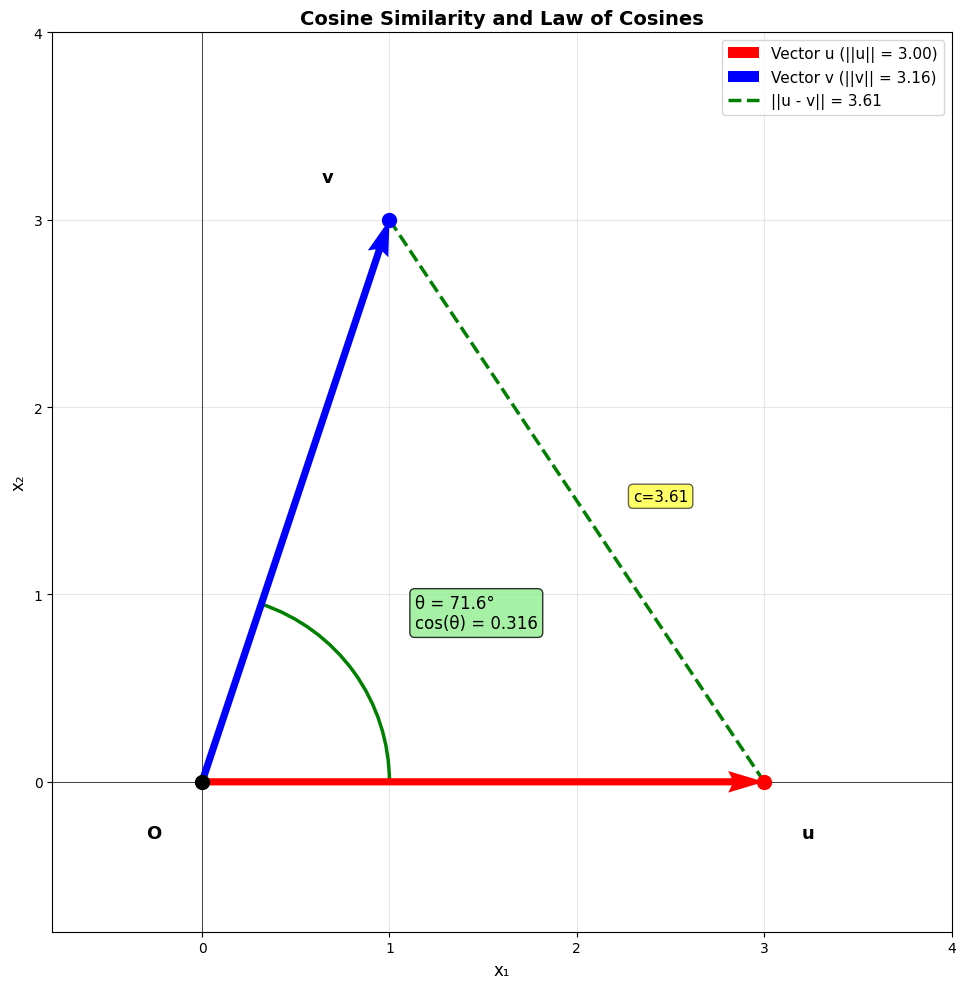

In [8]:
# Create a visualization showing vectors and the triangle formed
fig, ax = plt.subplots(figsize=(10, 10))

# Origin
origin = np.array([0, 0])

# Convert tensors to numpy for plotting
u_np = u.numpy()
v_np = v.numpy()
diff_np = (u - v).numpy()

# Plot vectors from origin
ax.quiver(origin[0], origin[1], u_np[0], u_np[1], angles='xy', scale_units='xy', scale=1, 
          color='red', width=0.008, label=f'Vector u (||u|| = {magnitude_u:.2f})', zorder=5)
ax.quiver(origin[0], origin[1], v_np[0], v_np[1], angles='xy', scale_units='xy', scale=1, 
          color='blue', width=0.008, label=f'Vector v (||v|| = {magnitude_v:.2f})', zorder=5)

# Plot the third side of the triangle (from u to v endpoint)
ax.plot([u_np[0], v_np[0]], [u_np[1], v_np[1]], 'g--', linewidth=2.5, 
        label=f'||u - v|| = {c:.2f}', zorder=4)

# Plot points at endpoints
ax.plot(*u_np, 'ro', markersize=10, zorder=6)
ax.plot(*v_np, 'bo', markersize=10, zorder=6)
ax.plot(*origin, 'ko', markersize=10, zorder=6)

# Draw angle arc
from matplotlib.patches import Arc
radius = 1.0
arc_angle = Arc((origin[0], origin[1]), 2*radius, 2*radius, 
                angle=0, theta1=np.degrees(np.arctan2(u_np[1], u_np[0])), 
                theta2=np.degrees(np.arctan2(v_np[1], v_np[0])), 
                color='green', linewidth=2.5, zorder=4)
ax.add_patch(arc_angle)

# Add angle label
mid_angle_rad = (np.arctan2(u_np[1], u_np[0]) + np.arctan2(v_np[1], v_np[0])) / 2
label_radius = 1.4
ax.text(label_radius * np.cos(mid_angle_rad), label_radius * np.sin(mid_angle_rad), 
        f'θ = {angle_deg.item():.1f}°\ncos(θ) = {cosine_similarity.item():.3f}', fontsize=12, 
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8), zorder=7)

# Add vertex labels
ax.text(u_np[0] + 0.2, u_np[1] - 0.3, 'u', fontsize=13, fontweight='bold', ha='left')
ax.text(v_np[0] - 0.3, v_np[1] + 0.2, 'v', fontsize=13, fontweight='bold', ha='right')
ax.text(origin[0] - 0.3, origin[1] - 0.3, 'O', fontsize=13, fontweight='bold')

# Add side length labels
ax.text((u_np[0] + v_np[0])/2 + 0.3, (u_np[1] + v_np[1])/2, f'c={c.item():.2f}', 
        fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.6))

# Set axis properties
ax.set_xlim(-0.8, 4)
ax.set_ylim(-0.8, 4)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('x₁', fontsize=12)
ax.set_ylabel('x₂', fontsize=12)
ax.set_title('Cosine Similarity and Law of Cosines', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

## Cosine Similarity with Different Vector Pairs

In [9]:
# Example 1: Identical direction (cosine similarity = 1)
v1 = torch.tensor([1.0, 2.0, 3.0])
v2 = torch.tensor([2.0, 4.0, 6.0])  # v2 = 2 * v1

cos_sim_1 = torch.dot(v1, v2) / (torch.norm(v1) * torch.norm(v2))
angle_1 = torch.rad2deg(torch.acos(cos_sim_1))
print(f"Example 1 - Parallel vectors:")
print(f"v1 = {v1}, v2 = {v2}")
print(f"Cosine Similarity = {cos_sim_1:.4f}, Angle = {angle_1:.2f}°\n")

# Example 2: Orthogonal vectors (cosine similarity = 0)
v3 = torch.tensor([1.0, 0.0, 0.0])
v4 = torch.tensor([0.0, 1.0, 0.0])  # perpendicular to v3

cos_sim_2 = torch.dot(v3, v4) / (torch.norm(v3) * torch.norm(v4))
angle_2 = torch.rad2deg(torch.acos(torch.clamp(cos_sim_2, -1, 1)))
print(f"Example 2 - Orthogonal vectors:")
print(f"v3 = {v3}, v4 = {v4}")
print(f"Cosine Similarity = {cos_sim_2:.4f}, Angle = {angle_2:.2f}°\n")

# Example 3: Opposite direction (cosine similarity = -1)
v5 = torch.tensor([1.0, 1.0, 1.0])
v6 = torch.tensor([-1.0, -1.0, -1.0])  # opposite to v5

cos_sim_3 = torch.dot(v5, v6) / (torch.norm(v5) * torch.norm(v6))
angle_3 = torch.rad2deg(torch.acos(torch.clamp(cos_sim_3, -1, 1)))
print(f"Example 3 - Opposite direction vectors:")
print(f"v5 = {v5}, v6 = {v6}")
print(f"Cosine Similarity = {cos_sim_3:.4f}, Angle = {angle_3:.2f}°")

Example 1 - Parallel vectors:
v1 = tensor([1., 2., 3.]), v2 = tensor([2., 4., 6.])
Cosine Similarity = 1.0000, Angle = 0.02°

Example 2 - Orthogonal vectors:
v3 = tensor([1., 0., 0.]), v4 = tensor([0., 1., 0.])
Cosine Similarity = 0.0000, Angle = 90.00°

Example 3 - Opposite direction vectors:
v5 = tensor([1., 1., 1.]), v6 = tensor([-1., -1., -1.])
Cosine Similarity = -1.0000, Angle = 180.00°


## Cosine Similarity vs Euclidean Distance

In [10]:
# Compare different similarity/distance metrics
vectors_a = torch.tensor([
    [1.0, 0.0, 0.0],
    [2.0, 0.0, 0.0],
    [1.0, 1.0, 0.0]
])

vectors_b = torch.tensor([
    [0.0, 1.0, 0.0],
    [0.0, 2.0, 0.0],
    [0.0, 1.0, 0.0]
])

print("Comparison of different metrics:\n")
for i in range(len(vectors_a)):
    va = vectors_a[i]
    vb = vectors_b[i]
    
    # Cosine Similarity
    cos_sim = torch.dot(va, vb) / (torch.norm(va) * torch.norm(vb))
    
    # Euclidean Distance
    euclidean_dist = torch.norm(va - vb)
    
    # Angle
    angle = torch.rad2deg(torch.acos(torch.clamp(cos_sim, -1, 1)))
    
    print(f"Pair {i+1}:")
    print(f"  Vector A: {va}")
    print(f"  Vector B: {vb}")
    print(f"  Cosine Similarity: {cos_sim:.4f}")
    print(f"  Euclidean Distance: {euclidean_dist:.4f}")
    print(f"  Angle: {angle:.2f}°\n")

Comparison of different metrics:

Pair 1:
  Vector A: tensor([1., 0., 0.])
  Vector B: tensor([0., 1., 0.])
  Cosine Similarity: 0.0000
  Euclidean Distance: 1.4142
  Angle: 90.00°

Pair 2:
  Vector A: tensor([2., 0., 0.])
  Vector B: tensor([0., 2., 0.])
  Cosine Similarity: 0.0000
  Euclidean Distance: 2.8284
  Angle: 90.00°

Pair 3:
  Vector A: tensor([1., 1., 0.])
  Vector B: tensor([0., 1., 0.])
  Cosine Similarity: 0.7071
  Euclidean Distance: 1.0000
  Angle: 45.00°



## Applications of Cosine Similarity

**Natural Language Processing (NLP):**
- Document similarity: Compare TF-IDF vectors of documents
- Word embeddings: Find similar words or sentences (Word2Vec, GloVe)
- Text clustering and classification
- Semantic similarity between phrases

**Information Retrieval:**
- Search ranking: Measure relevance of documents to queries
- Information filtering and recommendation

**Machine Learning:**
- Collaborative filtering for recommendations
- Clustering algorithms (K-means variations)
- Anomaly detection using vector similarity

**Computer Vision:**
- Image classification using feature vectors
- Face verification and recognition
- Semantic image retrieval

**Advantages:**
- Scale-invariant: magnitude doesn't affect similarity
- Computationally efficient compared to other similarity measures
- Works well for high-dimensional sparse data (like text)
- Interpretable: directly relates to angle between vectors

**Disadvantages:**
- Sensitive to negative correlations (treats them as dissimilar)
- Ignores magnitude differences (sometimes desirable, sometimes not)
- May not be ideal for dense vectors with negative values